In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("HR_DATA.csv")

In [48]:
df.head()

df.tail()

df.shape

df.columns

df.info()

df.describe()

df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Status,Work_Mode
count,2000000,2000000,2000000,2000000,2000000,2000000,2000000,2000000
unique,2000000,467487,7,29,5479,1593497,4,2
top,EMP0000001,Michael Smith,IT,Software Engineer,2022-10-31,"Lake Michael, Congo",Active,On-site
freq,1,1014,601042,300358,622,20,1401558,1199109


In [49]:
df.isnull().sum()

Unnamed: 0            0
Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df['Hire_Date']=pd.to_datetime(df['Hire_Date'])
df['Joining_Month']=df['Hire_Date'].dt.month_name()

In [52]:
len(df)

2000000

In [53]:
df["Department"].nunique()

7

In [54]:
dept = df['Department'].value_counts()
dept

Department
IT            601042
Sales         400031
Operations    300095
Marketing     240081
Finance       199873
HR            159119
R&D            99759
Name: count, dtype: int64

<Axes: xlabel='Department'>

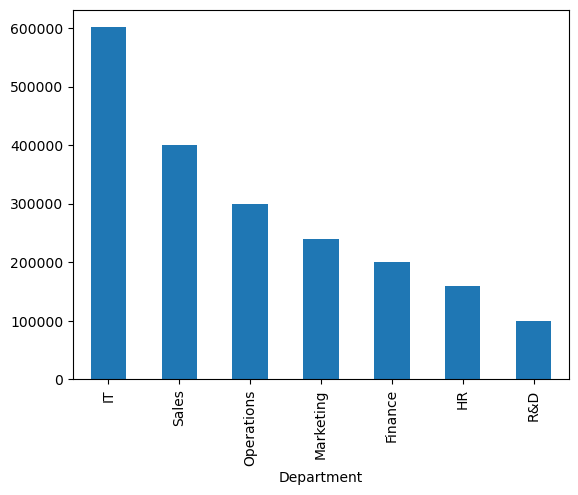

In [55]:
dept.plot(kind='bar')

In [56]:
df['Job_Title'].value_counts()

Job_Title
Software Engineer                300358
Sales Executive                  199982
Operations Executive             150058
Data Analyst                     120375
Marketing Executive              120154
Account Manager                  119929
Accountant                       100307
DevOps Engineer                   90197
Logistics Coordinator             90188
HR Executive                      79348
SEO Specialist                    71692
Business Development Manager      60233
IT Manager                        60224
Financial Analyst                 59815
Research Scientist                50017
Talent Acquisition Specialist     47994
Supply Chain Manager              44935
Content Strategist                36154
CTO                               29888
Product Developer                 29872
Finance Manager                   29799
HR Manager                        23841
Sales Director                    19887
Operations Director               14914
Lab Technician                

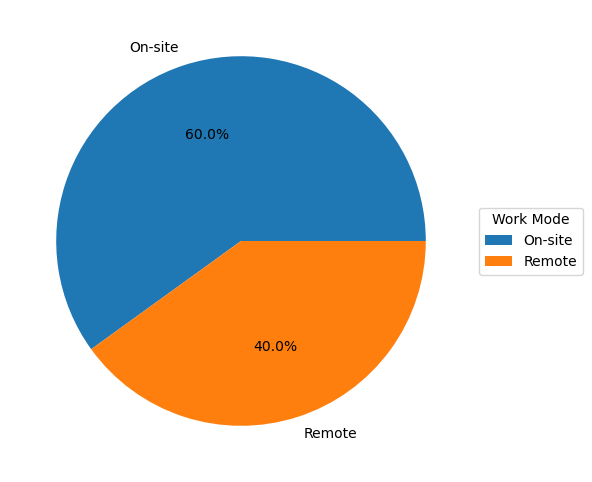

In [57]:
df['Work_Mode'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.legend(
    title='Work Mode',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.ylabel('')
plt.show()

In [58]:
df['Status'].value_counts()

Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: count, dtype: int64

In [59]:
attrition=(df['Status']=="Resigned").mean()*100
print(attrition)

19.933


In [60]:
df['Salary_INR'].mean()

np.float64(896887.7556635)

In [61]:
df['Salary_INR'].median()

811026.5

In [62]:
df['Salary_INR'].max()

2999976

In [63]:
df['Salary_INR'].min()

300000

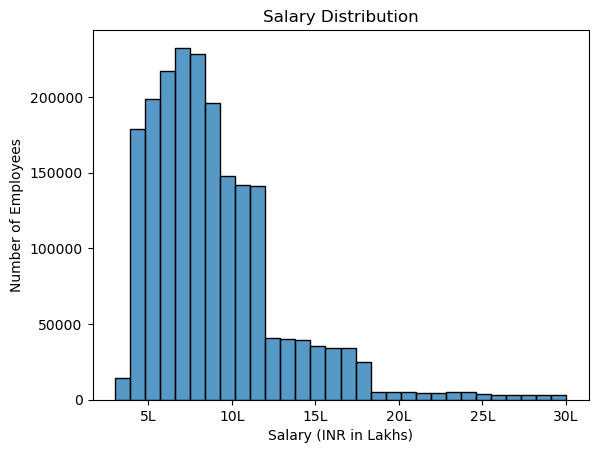

In [65]:
sns.histplot(df['Salary_INR'], bins=30)

plt.xlabel("Salary (INR in Lakhs)")
plt.ylabel("Number of Employees")
plt.title("Salary Distribution")

plt.xticks(
    [500000, 1000000, 1500000, 2000000, 2500000, 3000000],
    ['5L', '10L', '15L', '20L', '25L', '30L']
)

plt.show()

In [69]:
avg_salary = df.groupby('Department')['Salary_INR'].mean().sort_values()

print(avg_salary.round(0))

Department
HR             743854.0
Operations     754626.0
Marketing      769936.0
Sales          792958.0
R&D            800377.0
Finance        940412.0
IT            1129858.0
Name: Salary_INR, dtype: float64


In [ ]:
dept_salary = (df.groupby('Department')['Salary_INR'].mean() / 100000).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=dept_salary.index, y=dept_salary.values, palette='viridis')

for i, value in enumerate(dept_salary.values):
    ax.text(i, value, f'{value:.1f}L', ha='center', va='bottom')

plt.xlabel('Department')
plt.ylabel('Average Salary (INR in Lakhs)')
plt.title('Average Salary by Department')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [77]:
df['Performance_Rating'].value_counts()

Performance_Rating
4    400529
2    400174
3    399814
1    399756
5    399727
Name: count, dtype: int64

In [78]:
df['Performance_Rating'].value_counts(normalize=True).sort_index() * 100

Performance_Rating
1    19.98780
2    20.00870
3    19.99070
4    20.02645
5    19.98635
Name: proportion, dtype: float64

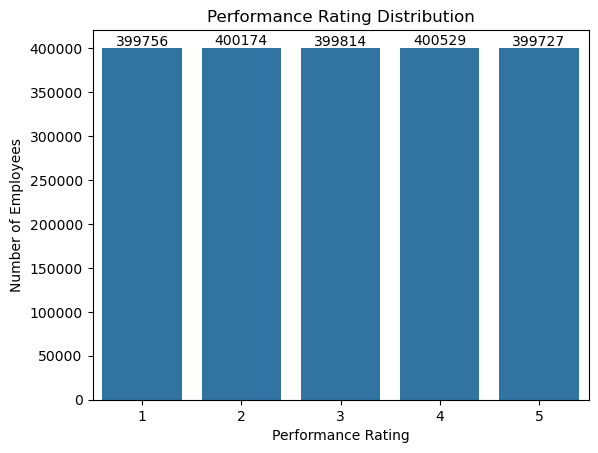

In [79]:
performance_counts = df['Performance_Rating'].value_counts().sort_index()

ax = sns.barplot(x=performance_counts.index, y=performance_counts.values)

for i, value in enumerate(performance_counts.values):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.title('Performance Rating Distribution')
plt.show()

In [ ]:
rating_by_department = pd.crosstab(df['Department'], df['Performance_Rating'])
rating_by_department_pct = rating_by_department.div(rating_by_department.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(rating_by_department_pct, annot=True, fmt='.1f', cmap='Blues')

plt.xlabel('Performance Rating')
plt.ylabel('Department')
plt.title('Performance Rating Share by Department (%)')
plt.show()

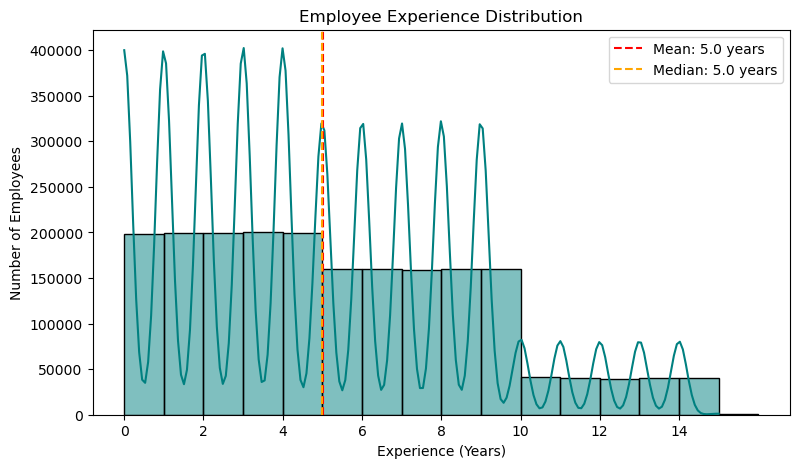

In [83]:
mean_exp = df['Experience_Years'].mean()
median_exp = df['Experience_Years'].median()

plt.figure(figsize=(9, 5))
sns.histplot(df['Experience_Years'], bins=range(0, int(df['Experience_Years'].max()) + 2), kde=True, color='teal')

plt.axvline(mean_exp, color='red', linestyle='--', label=f'Mean: {mean_exp:.1f} years')
plt.axvline(median_exp, color='orange', linestyle='--', label=f'Median: {median_exp:.1f} years')

plt.xlabel('Experience (Years)')
plt.ylabel('Number of Employees')
plt.title('Employee Experience Distribution')
plt.xticks(range(0, int(df['Experience_Years'].max()) + 1, 2))
plt.legend()
plt.show()

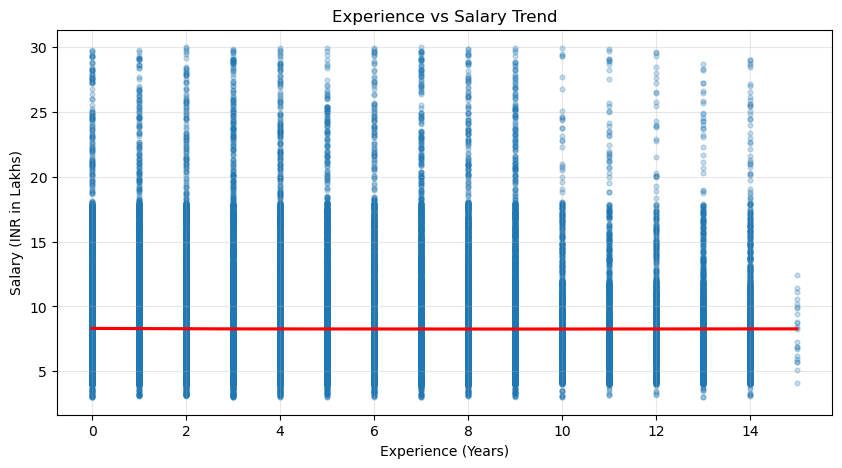

In [85]:
plot_df = df.sample(50000, random_state=42).copy()
plot_df['Salary_Lakhs'] = plot_df['Salary_INR'] / 100000

plt.figure(figsize=(10, 5))
sns.regplot(
    data=plot_df,
    x='Experience_Years',
    y='Salary_Lakhs',
    scatter_kws={'alpha': 0.25, 's': 12},
    line_kws={'color': 'red'},
    lowess=True
)

plt.xlabel('Experience (Years)')
plt.ylabel('Salary (INR in Lakhs)')
plt.title('Experience vs Salary Trend')
plt.grid(alpha=0.3)
plt.show()

In [88]:
df.groupby('Performance_Rating')['Salary_INR'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Performance_Rating,,,,
1,897349.444173,810569.0,300069,2999797
2,896712.984404,811488.5,300018,2999973
3,896273.208980,810518.0,300026,2999610
4,897389.988453,811807.0,300000,2999906
5,896712.440343,810725.0,300044,2999976


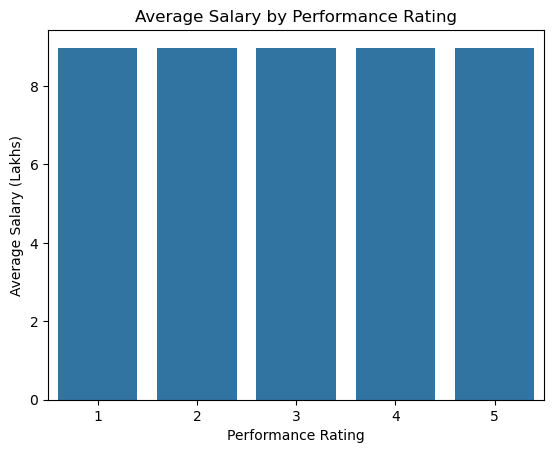

In [ ]:
box_df = df.sample(50000, random_state=42).copy()
box_df['Salary_Lakhs'] = box_df['Salary_INR'] / 100000

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=box_df,
    x='Performance_Rating',
    y='Salary_Lakhs',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 6}
)

plt.xlabel('Performance Rating')
plt.ylabel('Salary (INR in Lakhs)')
plt.title('Salary Distribution by Performance Rating')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [91]:
df['Joining_Year'] = df['Hire_Date'].dt.year
df['Joining_Year'].value_counts().sort_index()

Joining_Year
2010     15520
2011     40089
2012     39765
2013     39988
2014     40202
2015     85984
2016    160249
2017    160363
2018    159658
2019    160202
2020    175460
2021    199366
2022    201373
2023    198982
2024    200001
2025    122798
Name: count, dtype: int64

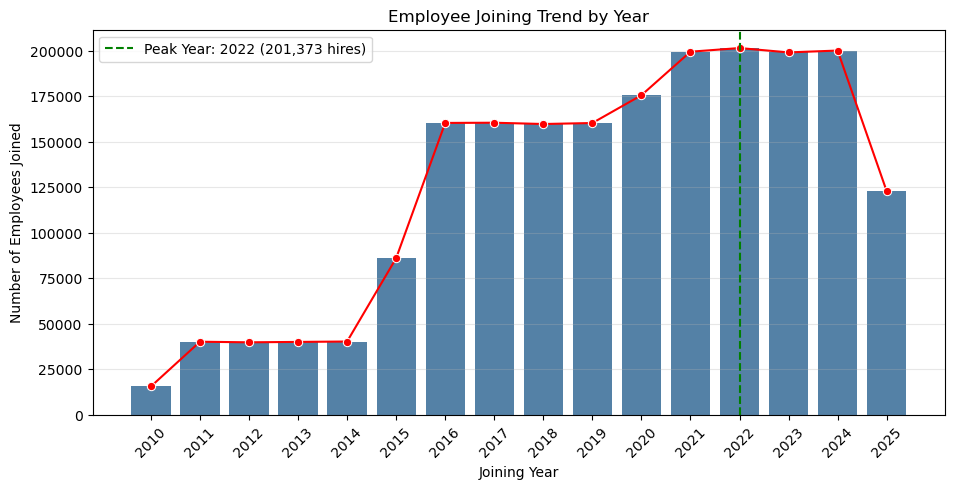

In [93]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Joining_Year'] = df['Hire_Date'].dt.year

joining_year_counts = df['Joining_Year'].value_counts().sort_index()
peak_year = joining_year_counts.idxmax()
peak_count = joining_year_counts.max()

plt.figure(figsize=(11, 5))
sns.barplot(x=joining_year_counts.index, y=joining_year_counts.values, color='steelblue')
sns.lineplot(x=range(len(joining_year_counts)), y=joining_year_counts.values, color='red', marker='o')

plt.axvline(list(joining_year_counts.index).index(peak_year), color='green', linestyle='--', label=f'Peak Year: {peak_year} ({peak_count:,} hires)')
plt.xlabel('Joining Year')
plt.ylabel('Number of Employees Joined')
plt.title('Employee Joining Trend by Year')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

In [ ]:
top_locations = df['Location'].value_counts().head(10)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=top_locations.values, y=top_locations.index, palette='mako')

for i, value in enumerate(top_locations.values):
    ax.text(value, i, f' {value:,}', va='center')

plt.xlabel('Number of Employees')
plt.ylabel('Location')
plt.title('Top 10 Employee Locations')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
work_mode_dept = pd.crosstab(df['Department'], df['Work_Mode'])
work_mode_dept_pct = work_mode_dept.div(work_mode_dept.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 5))
sns.heatmap(work_mode_dept_pct, annot=True, fmt='.1f', cmap='YlGnBu')

plt.xlabel('Work Mode')
plt.ylabel('Department')
plt.title('Work Mode Share by Department (%)')
plt.show()

In [ ]:
attrition_by_work_mode = (df.assign(Is_Resigned=df['Status'].eq('Resigned'))
                         .groupby('Work_Mode')['Is_Resigned']
                         .mean()
                         .mul(100)
                         .sort_values(ascending=False))

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=attrition_by_work_mode.index, y=attrition_by_work_mode.values, palette='rocket')

for i, value in enumerate(attrition_by_work_mode.values):
    ax.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.xlabel('Work Mode')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Work Mode')
plt.ylim(0, attrition_by_work_mode.max() * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.show()

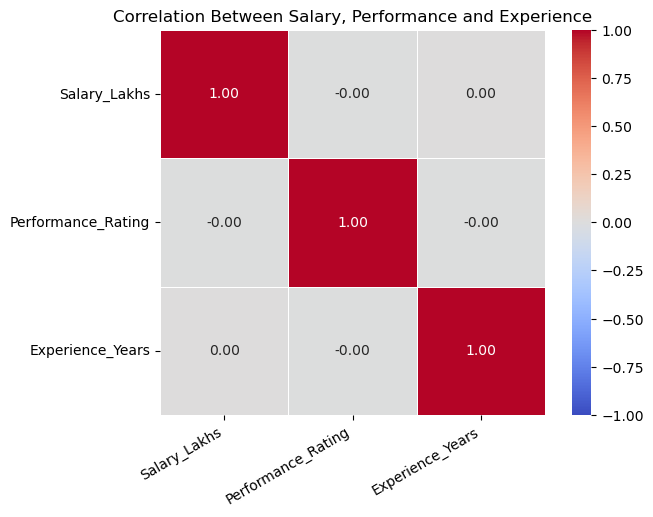

In [98]:
corr_df = df[['Salary_INR', 'Performance_Rating', 'Experience_Years']].copy()
corr_df['Salary_Lakhs'] = corr_df['Salary_INR'] / 100000
corr_df = corr_df[['Salary_Lakhs', 'Performance_Rating', 'Experience_Years']]

corr = corr_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Between Salary, Performance and Experience')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.show()

In [99]:
summary_metrics = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Departments',
        'Job Titles',
        'Locations',
        'Average Salary (Lakhs)',
        'Median Salary (Lakhs)',
        'Average Experience (Years)',
        'Attrition Rate (%)'
    ],
    'Value': [
        len(df),
        df['Department'].nunique(),
        df['Job_Title'].nunique(),
        df['Location'].nunique(),
        round(df['Salary_INR'].mean() / 100000, 2),
        round(df['Salary_INR'].median() / 100000, 2),
        round(df['Experience_Years'].mean(), 2),
        round((df['Status'].eq('Resigned').mean() * 100), 2)
    ]
})

summary_metrics

,Metric,Value
0,Total Employees,2000000.00
1,Departments,7.00
2,Job Titles,29.00
3,Locations,1593497.00
4,Average Salary (Lakhs),8.97
5,Median Salary (Lakhs),8.11
6,Average Experience (Years),5.01
7,Attrition Rate (%),19.93


C:\Users\monti\AppData\Local\Temp\ipykernel_1164\1820227155.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='crest')


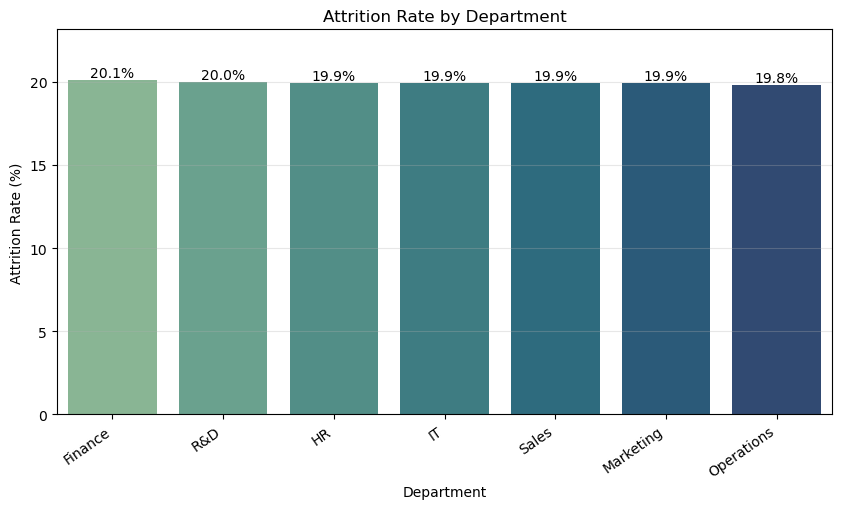

In [100]:
attrition_by_dept = (df.assign(Is_Resigned=df['Status'].eq('Resigned'))
                     .groupby('Department')['Is_Resigned']
                     .mean()
                     .mul(100)
                     .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='crest')

for i, value in enumerate(attrition_by_dept.values):
    ax.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, attrition_by_dept.max() * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\monti\AppData\Local\Temp\ipykernel_1164\634667228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_job_salary.values, y=top_job_salary.index, palette='flare')


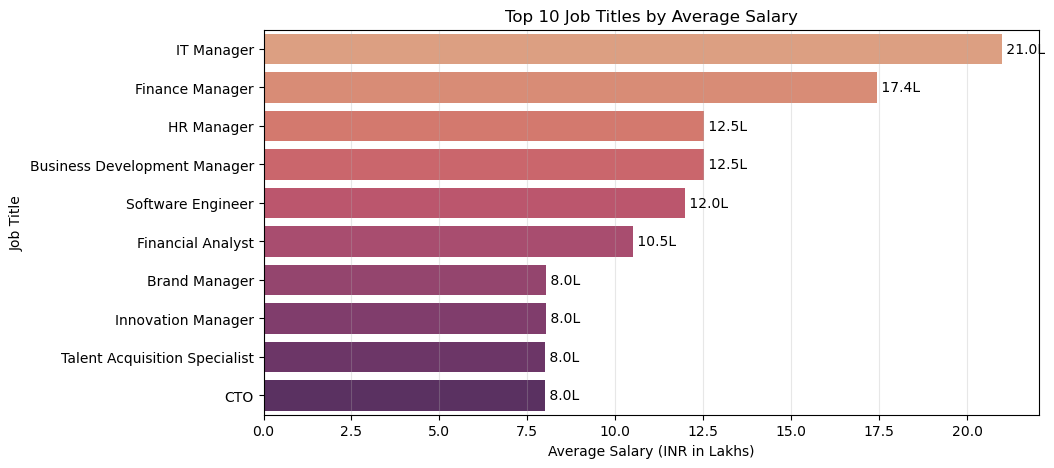

In [101]:
top_job_salary = (df.groupby('Job_Title')['Salary_INR']
                  .mean()
                  .div(100000)
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=top_job_salary.values, y=top_job_salary.index, palette='flare')

for i, value in enumerate(top_job_salary.values):
    ax.text(value, i, f' {value:.1f}L', va='center')

plt.xlabel('Average Salary (INR in Lakhs)')
plt.ylabel('Job Title')
plt.title('Top 10 Job Titles by Average Salary')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Key Insights

- The dataset contains **2,000,000 employees** across **7 departments**, **29 job titles**, and **1,593,497 unique locations**.
- The average salary is approximately **8.97 lakhs**, while the median salary is **8.11 lakhs**. This indicates that the salary distribution is slightly stretched toward higher salary values.
- The average employee experience is approximately **5.01 years**, which suggests that the workforce is mostly in the mid-experience range.
- The overall attrition rate is **19.93%**, making employee retention an important area to monitor.
- The largest department is **IT**, with **601,042 employees**.
- The **IT department** also has the highest average salary, at approximately **11.30 lakhs**.
- The highest attrition rate is observed in the **Finance department**, at approximately **20.13%**.
- Performance ratings are almost evenly distributed, with each rating category from 1 to 5 representing around **20%** of employees. This suggests that the rating column may be balanced or synthetic.
- The correlation between salary and experience is approximately **0.00**, meaning experience does not strongly explain salary variation in this dataset.
- The correlation between salary and performance rating is approximately **-0.00**, meaning there is no clear linear relationship between performance rating and salary.
- The peak hiring year is **2022**, with **201,373 employees** joining in that year.
- Based on work mode, the highest attrition is among **Remote** employees, at approximately **19.95%**, although the difference appears very small.

### Final Conclusion

In this dataset, salary differences appear to be more meaningful across departments and job titles. Performance rating and experience do not show a strong relationship with salary. The overall attrition rate is close to 20%, so department-wise attrition analysis can provide useful HR insights.